# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Researchers collected data from a Portugese bank covering 17 campaigns conducted with a total of 79354 customer contacts

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [26]:
import pandas as pd

In [27]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [28]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [20]:
#Let's check if there is na in the data set
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [29]:
#Sum of the unknown columns
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [25]:
#Lets find the percentage of the unknown data per column
unknown_counts = (df == 'unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0]

unknown_percent = (unknown_counts / len(df)) * 100

pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Percentage': unknown_percent.round(2)
})

,Unknown Count,Percentage
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40


Six categorical features contain unknown values as presented in the table above. The Default feature has the highest proportion of unknown values at 20.8%. Marital has the lowest at 0.19%. I am not going to throw away unknown defaults since it constitutes 20% of the data.

In [35]:
df['default'].value_counts()


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [33]:
#Let's take a look at importance of default with respect to long term deposists

pd.crosstab(
    df['default'],
    df['y'],
    normalize='index'
).round(3) * 100

y,no,yes
default,,
no,87.1,12.9
unknown,94.8,5.2
yes,100.0,0.0


The default feature contains three categories: no, unknown, and yes. Customers with default = no had a term-deposit subscription rate of 12.9%, compared with 5.2% for customers with default = unknown. The default = yes category had a 0% subscription rate, but this category contains only three observations, so it is too small to draw reliable conclusions.

In [37]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [39]:
#Percentage of observations in each category of y
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

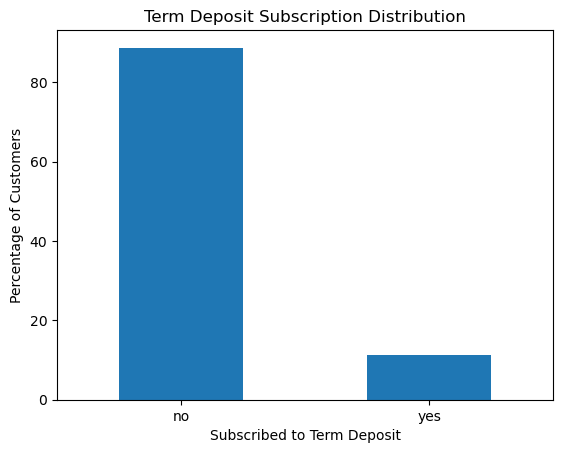

In [42]:
#Let's bar graph the term deposit subscription distribution between yes and no in terms of percentages
import matplotlib.pyplot as plt


df['y'].value_counts(normalize=True).mul(100).plot(kind='bar')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.show()

88.73% of customers did not subscribe to a term deposit, while 11.27% subscribed. Therefore, the target variable is imbalanced, with substantially more customers in the no class.

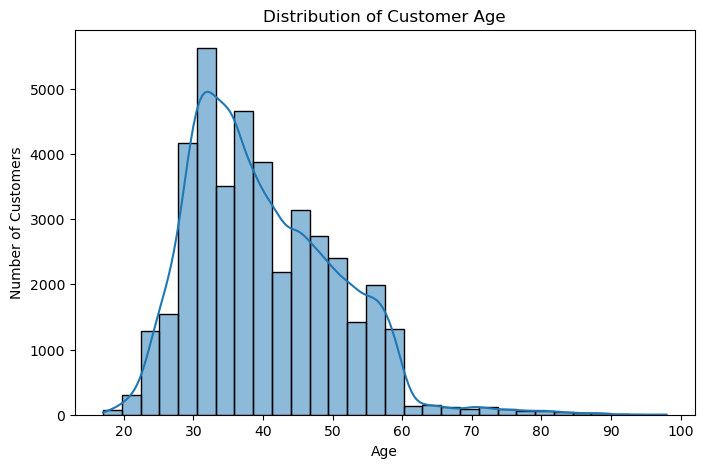

In [82]:
#Let's take a look at the age distribution of the customers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

Majority of the customers are between 30s and 40s.

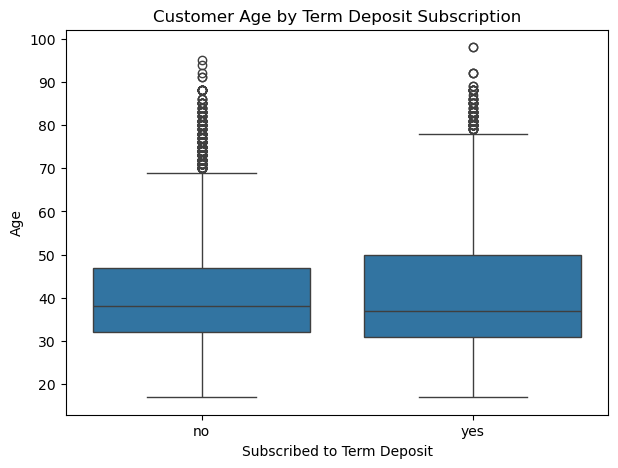

In [87]:
#Box plot of age versus subscription
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='y', y='age')

plt.title('Customer Age by Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Age')
plt.show()

The box plot shows that age distribution of customers who subscribed has a wider interquantile range than the distribution of customers who didn't subscribe.

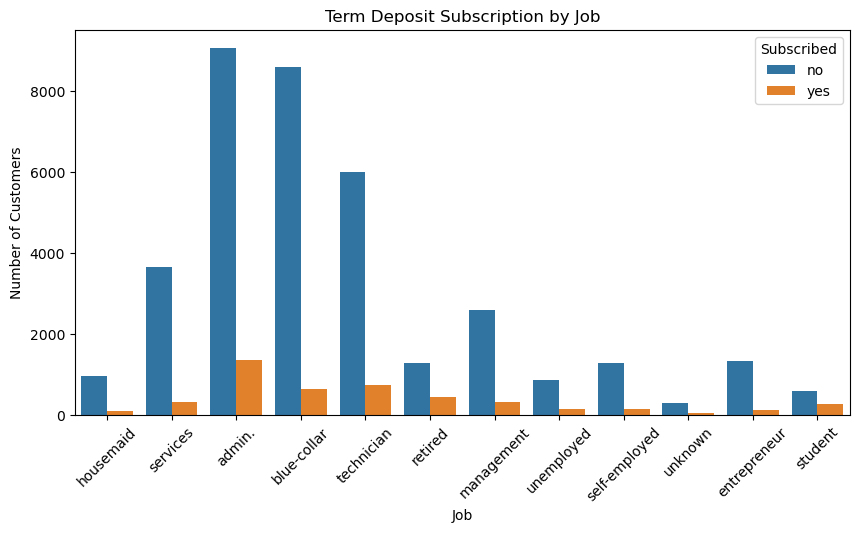

In [88]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='job',
    hue='y'
)

plt.title('Term Deposit Subscription by Job')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Subscribed')

plt.show()

From the graph we see that admin workers mostly subscribed to a term deposit.

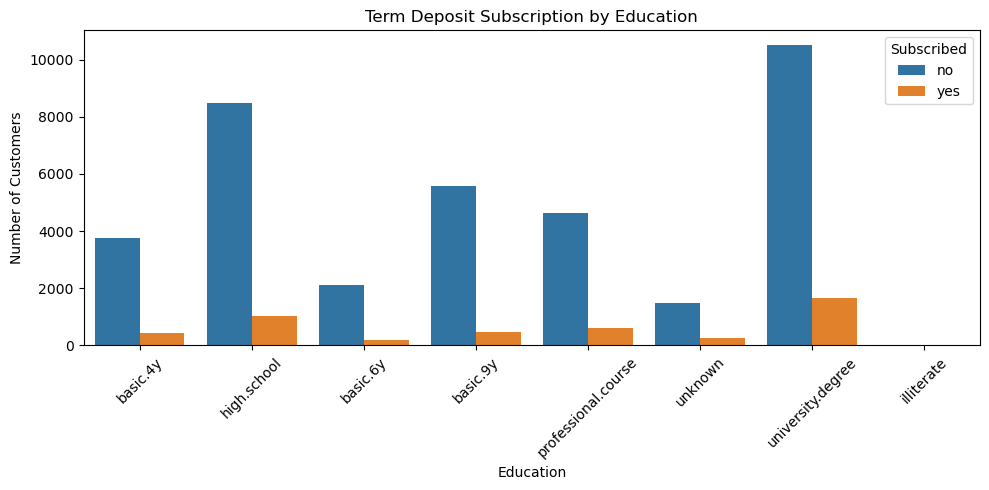

In [98]:
#Let's plot education vs Subscription
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='education',
    hue='y'
)

plt.title('Term Deposit Subscription by Education')
plt.xlabel('Education')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Subscribed')

plt.tight_layout()
plt.show()

Customers with university and high school degree account for a bigger number of long term loan subscriptions.

<Axes: >

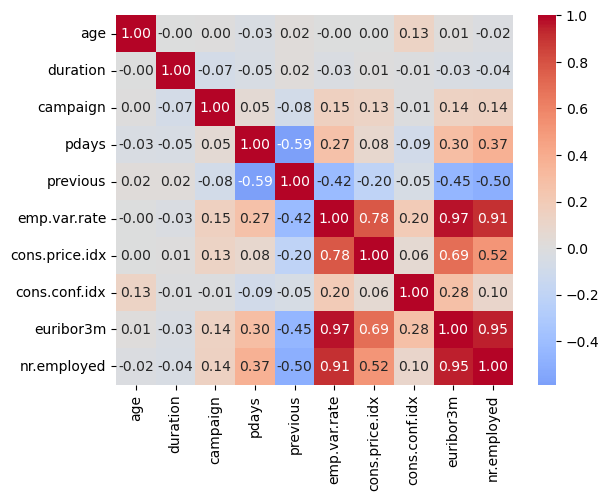

In [99]:
#Let's look at the correlation heat map
numeric_data = df.select_dtypes(include='number')

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

Euribor 3 month rate, employment variation rate, number of employees employed indicators and consumption price index are highly correlated.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The business objective I am trying to solve is to develop a predictive model that identifies customers who are most likely to subscribe to a term deposit. The bank can use these predictions to target its marketing campaigns more effectively, increasinf subscription rates

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [55]:
#Let's prepare the data
X = df.drop('y', axis=1)
y = df['y'].map({'no': 0, 'yes': 1})

In [56]:
#Let's seperate categorical and numerical features
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

In [57]:
print("Categorical:", list(categorical_features))
print("Numerical:", list(numerical_features))

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [60]:
X_encoded = preprocessor.fit_transform(X)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [63]:
from sklearn.model_selection import train_test_split

#I will do 80/20 train, test split beacuse it will give our model enough room to learn from. Stratify = y will balance the data for y values
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [64]:
#This will give a good picture of how train and test data is split.
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(32950, 20)
(8238, 20)
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [89]:
baseline = y.value_counts(normalize=True).max()
print(f"Baseline accuracy: {baseline:.2%}")

Baseline accuracy: 88.73%


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
y_pred = logreg_model.predict(X_test)

In [93]:
# Get feature names after preprocessing
feature_names = logreg_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logreg_model.named_steps[
    'classifier'
].coef_[0]

# Create a DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Display the 10 largest positive coefficients
coef_df.sort_values(
    'Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
40,cat__month_mar,1.640903
54,num__duration,1.199467
59,num__cons.price.idx,1.177989
61,num__euribor3m,0.610467
36,cat__month_aug,0.509778
5,cat__job_retired,0.324348
62,num__nr.employed,0.286991
20,cat__education_illiterate,0.215057
52,cat__poutcome_success,0.210278
8,cat__job_student,0.132872


Customers contacted in March have higher prodicted log odds of subscribing comapred with the reference month. Longer call duration is associated with higher predicted log odds of subscription.

In [96]:
# Display the 10 largest negative coefficients
coef_df.sort_values(
    'Coefficient',
    ascending=True
).head(10)

,Feature,Coefficient
58,num__emp.var.rate,-2.600061
39,cat__month_jun,-0.766027
41,cat__month_may,-0.754961
42,cat__month_nov,-0.719316
34,cat__contact_telephone,-0.657522
50,cat__poutcome_failure,-0.619762
25,cat__default_unknown,-0.486241
35,cat__month_apr,-0.294876
1,cat__job_blue-collar,-0.292462
51,cat__poutcome_nonexistent,-0.269540


Higher employment variation rate is strongly associated with lower predicted log odds of subscribing. Additionally, customers contacted in Jun and May have lower predicted log odds of subscribing compared with the reference month.

### Problem 9: Score the Model

What is the accuracy of your model?

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.2%}")

Logistic Regression Accuracy: 91.66%


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [72]:
import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start_time

    train_accuracy = pipeline.score(X_train, y_train)
    test_accuracy = pipeline.score(X_test, y_test)

    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })

In [73]:
results_df = pd.DataFrame(results)

results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.330645,0.910167,0.916606
1,KNN,0.066851,0.927739,0.907623
2,Decision Tree,0.246959,1.000000,0.892935
3,SVM,11.427323,0.922155,0.915392


The Logistic Regression model performed best overall, with approximately 91% training accuracy and 92% test accuracy. The Decision Tree achieved 100% training accuracy but only 89% test accuracy, which suggests that the model is overfitting the training data and does not generalize as well to unseen data. The relatively small difference between the Logistic Regression training and test accuracy suggests better generalization.
Accuracy was used as the initial evaluation metric because it measures the proportion of customers that the model classified correctly. However, the target variable is imbalanced, with approximately 88.7% of customers not subscribing to a term deposit and 11.3% subscribing. Therefore, accuracy alone may not fully describe model performance. Precision, recall, F1 score, and the confusion matrix should also be considered, particularly when evaluating the model's ability to identify customers who subscribe to a term deposit.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [74]:
#Create the four models
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100]
    },

    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11]
    },

    'Decision Tree': {
        'model__max_depth': [2, 5, 10, 20, None]
    },

    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto']
    }
}

In [75]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

In [76]:
#Create and measure the training time
grid_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    start_time = time.time()

    grid.fit(X_train, y_train)

    train_time = time.time() - start_time

    grid_results.append({
        'Model': name,
        'Best Parameters': grid.best_params_,
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy': grid.score(X_test, y_test),
        'Train Time': train_time
    })

In [77]:
#Create the data frame
grid_results_df = pd.DataFrame(grid_results)

grid_results_df

,Model,Best Parameters,Best CV Accuracy,Test Accuracy,Train Time
0,Logistic Regression,{'model__C': 10},0.909833,0.916363,4.471972
1,KNN,{'model__n_neighbors': 11},0.904401,0.909444,4.601642
2,Decision Tree,{'model__max_depth': 5},0.911958,0.918548,1.145870
3,SVM,"{'model__C': 10, 'model__gamma': 'auto'}",0.909954,0.914542,81.115812


After hyperparameter tuning, the Decision Tree achieved the highest test accuracy at 91.85% with a maximum depth of 5 in this experiment. This represents an improvement over the original Decision Tree, which had 100% training accuracy but only 89.29% test accuracy and showed signs of overfitting. Logistic Regression achieved a test accuracy of 91.64%, SVM achieved 91.45%, and KNN achieved 90.94%. Although SVM performed reasonably well, its grid search required more training time than the other models.

Here are the findings from my analysis:
The target variable whether client is subscribed a term deposit or not is imbalanced: 88.73% no vs. 11.27% yes.
The original Decision Tree showed overfitting during modeling.
Hyperparameter tuning improved the Decision Tree's test accuracy from 89.29% to 91.85%.
Tuned Decision Tree is found to have the highest test accuracy in this exercise.
Logistic Regression was very close at 91.64%.
SVM required substantially more grid-search time (81.12 seconds).

Actionable Insights: 
The classification models can potentially help the bank identify customers who are more likely to subscribe to a term deposit. This could allow marketing teams to prioritize customers instead of treating all customers equally. Because only a relatively small percentage of customers subscribe, the bank should focus on identifying subscribers correctly rather than relying only on overall accuracy. 


Recommendations:
The bank should consider using model predictions as one input for prioritizing marketing campaigns. Before deploying a model, precision, recall, F1 score, and the confusion matrix should be evaluated in addition to accuracy. 

##### Questions